In [75]:
setwd("~/Project/ContinueEffectsRcode")

In [76]:
getwd()

[1] "/mnt/volume/home/hyx92/Project/ContinueEffectsRcode"


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Rows: 712 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (15): HR(t), Cal(t), Inte(t), METs(t), Steps(t), HR(t-1), Cal(t-1), Int...
dttm  (1): Timestamp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


正在处理: HR(t) 
正在处理: Cal(t) 
正在处理: Inte(t) 
正在处理: METs(t) 
正在处理: Steps(t) 
正在处理: HR(t-1) 
正在处理: Cal(t-1) 
正在处理: Inte(t-1) 
正在处理: METs(t-1) 
正在处理: Steps(t-1) 
正在处理: HR(t-2) 
正在处理: Cal(t-2) 
正在处理: Inte(t-2) 
正在处理: METs(t-2) 
正在处理: Steps(t-2) 


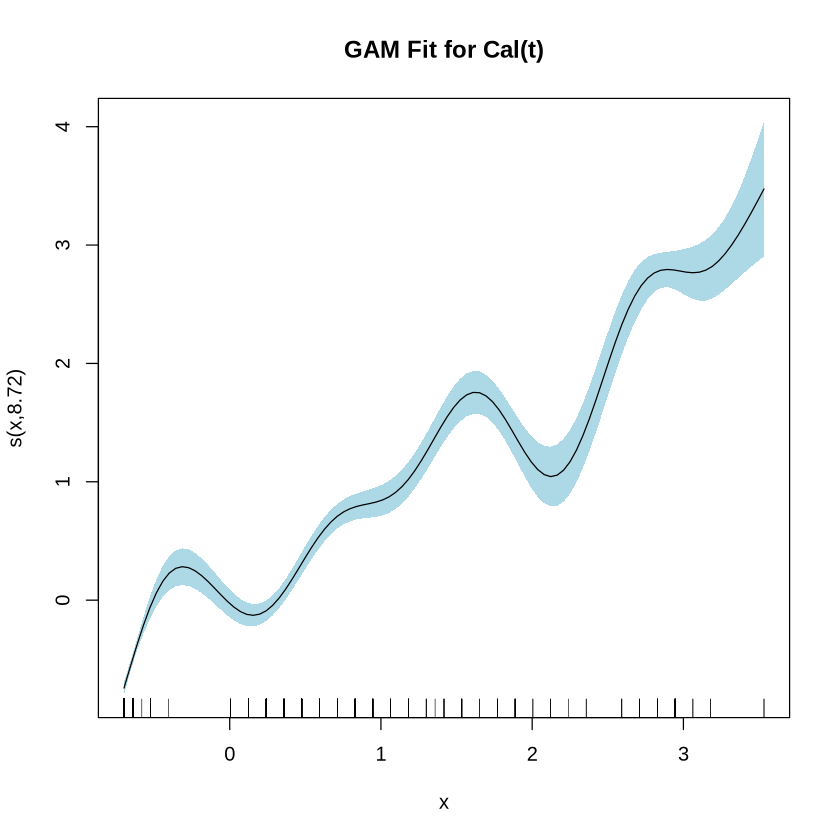

In [3]:
source("Application/Binning.R")

In [2]:
source("Application/Heart_boot.R")

Timing stopped at: 0.086 0.037 41.83



In [1]:
source("Application/Heart_application.R")


Attaching package: ‘bnlearn’


The following objects are masked from ‘package:pcalg’:

    dsep, pdag2dag, shd, skeleton


corrplot 0.95 loaded


Attaching package: ‘igraph’


The following objects are masked from ‘package:bnlearn’:

    as.igraph, compare, degree, subgraph


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-10

Non-function objects are not currently inserted (not traceable): .packageName

Modified functions inserted through trace(): definestartspace

Non-function objec

[1] "Initializing parameters and DAG..."
Estimating correlation matrix...
Smallest eigenvalue of the estimated correlation matrix is 0.01962858 ...
[1] "Refining parameters..."
[1] "SEM iteration starts..."
[1] "Updating expected statistics..."
maximum parent set size is 5 
core space defined, score table are being computed 
score tables completed, iterative MCMC is running 
search space expansion 2 
Estimating parameters...
Time difference of 0.02766228 secs
[1] "Updating expected statistics..."
maximum parent set size is 4 
core space defined, score table are being computed 
score tables completed, iterative MCMC is running 
search space expansion 2 
search space expansion 3 
Estimating parameters...
Time difference of 0.01982331 secs
PDAG SHD:  8 
[1] "Updating expected statistics..."
maximum parent set size is 4 
core space defined, score table are being computed 
score tables completed, iterative MCMC is running 
search space expansion 2 
Estimating parameters...
Time difference o

In [80]:
load("data/Sportinjury_Effects_500.RData")
#Generate list of effects for each int-out couple
effects4couple<-vector(mode="list", 15)
for (i in 1:15){
  effects4couple[[i]]<-vector(mode="list",15)
  for (j in 1:15){
    effects4couple[[i]][[j]]<-vector(mode="list",500)
    for (k in c(1:500)){
      effects4couple[[i]][[j]][[k]]<-Effects[[k]][[i]][[j]]
    }
  }
}


In [136]:
######### Plots Rain PLot New 
# Preallocate the data frame for plotting Effects 9 on 10 
Effects511 <- effects4couple[[15]][[6]]
total_rows <- 500 * 4 * 6  # Total iterations#对于水平1，2，3，4；有1，2，3,4 这4个基础水平，有6个变化水平
data <- data.frame(Level = integer(total_rows),
                   Change = integer(total_rows),
                   OCE = numeric(total_rows))


row_index <- 1
for (i in 1:500) {
  for (l in 1:4) {
    for (k in 1:6) {
      if (k %in% c(1, 2, 3)) {
        data[row_index, ] <- c(l, k, Effects511[[i]][,,l][1, k + 1 ])
      } 
      else if(k %in% c(4,5)){
        data[row_index, ] <- c(l, k, Effects511[[i]][,,l][2, k - 1])
      }
      else {
        data[row_index, ] <- c(l, k, Effects511[[i]][,,l][3, 4])
      }
      row_index <- row_index + 1
    }
  }
}


data$Change <- as.factor(data$Change)
data$Level <- as.factor(data$Level)
save(data, file = "data/DataInt156_For_Plots_500.RData")

Warning message in x + params$x:
“longer object length is not a multiple of shorter object length”
Warning message in x + params$x:
“longer object length is not a multiple of shorter object length”
Warning message in x + params$x:
“longer object length is not a multiple of shorter object length”
Warning message in x + params$x:
“longer object length is not a multiple of shorter object length”
Warning message in x + params$x:
“longer object length is not a multiple of shorter object length”
Warning message in x + params$x:
“longer object length is not a multiple of shorter object length”


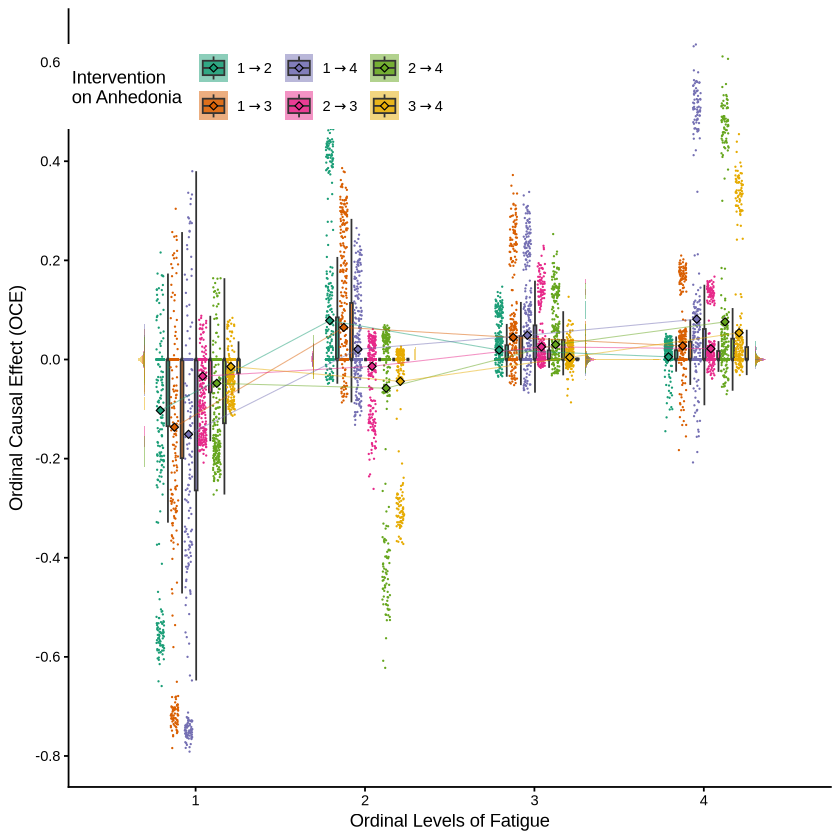

In [137]:
#plot code
load("data/DataInt156_For_Plots_500.RData")
library(ggplot2)
library(ggrain)
#Effects of changing variable 9 to the four levels of variable 10 
ggplot(data, aes(x = Level, y = OCE, fill = 	Change)) +
  geom_rain(alpha = .5, rain.side = 'f', cov = "Change", 
            boxplot.args = list(outlier.shape = NA, alpha = .8),
            violin.args = list(alpha = .5, color = NA),
            point.args=list(size=0.01),
            point.args.pos = list(position = position_jitterdodge(
              jitter.width = 0.18,
              jitter.height = 0,
              dodge.width = 0.5,
              seed = 42
            )),
            boxplot.args.pos = list(width = .1,
                                    position = ggpp::position_dodgenudge(width = 0.5,
                                                                         x = 0.045)),
            violin.args.pos = list(width = 0.9,
                                   position = position_nudge(x = c(rep(rep(-.3, 256*2),12), rep(rep(.3, 256*2),12)
                                   ))
            )) +
  theme_classic() +
  scale_y_continuous(
    breaks = seq(-4,4, by = 0.2), labels = scales::comma # Adjust break interval
  ) +
  stat_summary(fun = mean, geom = "line", aes(group = Change, color = Change),
               position = position_dodge(width = 0.5), linewidth = 0.3, alpha = 0.5) +
  stat_summary(fun = mean, geom = "point", aes(group = Change, color = Change),
               position = position_dodge(width = 0.5), size = 1.5, pch = 23, alpha = 1, color = "black") +
  scale_fill_manual(name="Intervention \non Anhedonia ",
                    labels=c(expression(1 %->% 2),expression(1 %->% 3),expression(1 %->% 4), expression(2 %->% 3 ), expression(2 %->% 4), expression(3 %->% 4)), values=c("#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02" ,"#A6761D","#666666"))  +
  scale_color_manual(values=c("#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02" ,"#A6761D","#666666"))+
  guides(
    fill = guide_legend(position = "inside"), color = 'none')+
  theme(legend.direction="horizontal", legend.position.inside = c(0.25, 0.9), #legend.key.size = unit(1.5, 'cm'), legend.title = element_text(size = 15),
        #legend.text = element_text(size = 10)
        )+
  labs(x="Ordinal Levels of Fatigue", y = "Ordinal Causal Effect (OCE)")


ggsave(file="Figure/Effect156.pdf", width = 210, height = 149.5, units = "mm")


Rows: 712 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (15): HR(t), Cal(t), Inte(t), METs(t), Steps(t), HR(t-1), Cal(t-1), Int...
dttm  (1): Timestamp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in newton(lsp = lsp, X = G$X, y = G$y, Eb = G$Eb, UrS = G$UrS, L = G$L, :
“Fitting terminated with step failure - check results carefully”
Warning message:
“Failed to fit group -1.
Caused by error in `smooth.construct.tp.smooth.spec()`:
! A term has fewer unique covariate combinations than specified maximum degrees of freedom”
Warning message:
“Failed to fit group -1.
Caused by error in `smooth.construct.tp.smooth.spec()`:
! A term has fewer unique covariate combinations than specified maximum degrees of freedom”
Warning message:
“Failed to fit group -1.
Caused by error in `smooth.construct.tp.smooth.sp

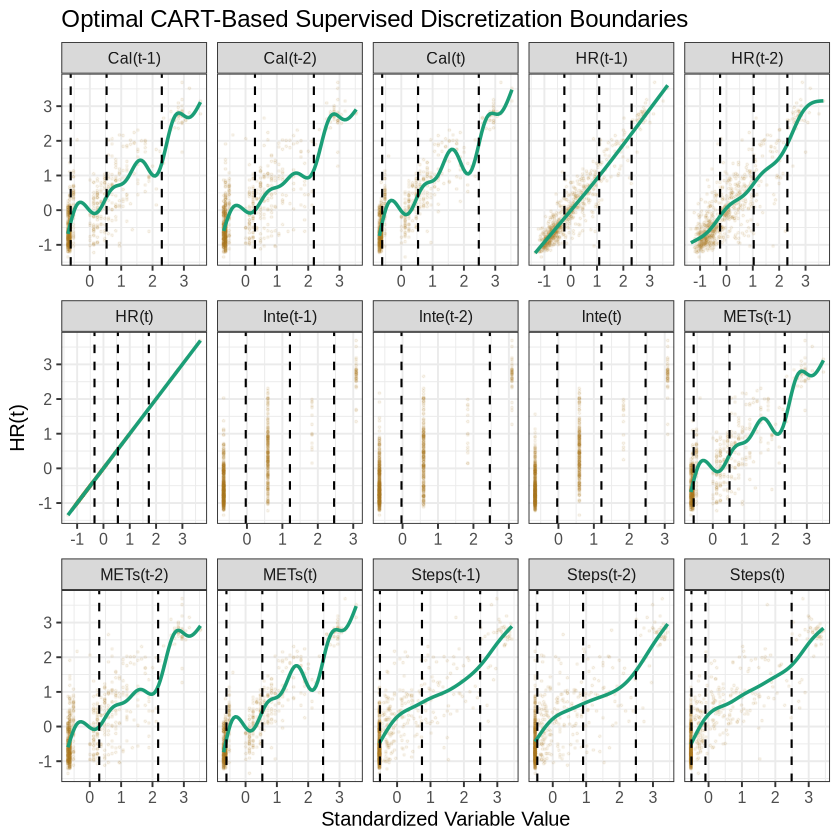

In [148]:
# =============================
# Visualize CART optimal split points
# (including HR(t))
# =============================

rm(list = ls())

library(readr)
library(dplyr)
library(rpart)
library(mgcv)
library(ggplot2)

# 读取数据
data <- read_csv("data/heart_data.csv")

# 删除第6列
data <- data %>% select(-6)

# 标准化
data <- as.data.frame(scale(data))

plot_data <- data.frame()
cut_data  <- data.frame()


for(col in names(data)){

  x <- data[[col]]

  # 目标变量仍然使用 HR(t)
  y <- data$`HR(t)`

  temp_df <- data.frame(
    Variable = col,
    x = x,
    y = y
  )

  plot_data <- rbind(plot_data, temp_df)

  fit <- rpart(
    y ~ x,
    method = "anova",
    control = rpart.control(
      maxdepth = 2,
      cp = 0.001
    )
  )

  if(!is.null(fit$splits)){

    cuts <- sort(unique(fit$splits[, "index"]))

    cut_df <- data.frame(
      Variable = rep(col,length(cuts)),
      cut = cuts
    )

    cut_data <- rbind(cut_data,cut_df)
  }
}

# 绘图
p <- ggplot(plot_data,
       aes(x = x,
           y = y)) +

  geom_point(
    alpha = 0.08,
    size = 0.4,
    color = "#A6761D"
  ) +

  geom_smooth(
    method = "gam",
    formula = y ~ s(x),
    se = FALSE,
    linewidth = 1,
    color = "#1B9E77"
  ) +

  geom_vline(
    data = cut_data,
    aes(xintercept = cut),
    linetype = "dashed",
    linewidth = 0.6
  ) +

  facet_wrap(
    ~Variable,
    scales = "free_x",
    ncol = 5
  ) +

  theme_bw(base_size = 12) +

  labs(
    x = "Standardized Variable Value",
    y = "HR(t)",
    title = "Optimal CART-Based Supervised Discretization Boundaries"
  )
print(p)

# 保存图片
ggsave(
  "CART_Discretization_All_Variables.png",
  p,
  width = 15,
  height = 10,
  dpi = 600
)